
# Superando el Olvido: LSTM (Long Short-Term Memory) 🧠🔋

En el notebook anterior usamos una **SimpleRNN** para pronosticar exportaciones de café. Usualmente, ese modelo:

- sigue bien la **tendencia inmediata**,
- pero se queda corto para **patrones de más largo plazo** (picos estacionales, ciclos climáticos).

Esto no es “culpa” de los datos: es una limitación típica del entrenamiento de RNNs llamada:

👉 **Gradiente desvaneciente (vanishing gradient)**

En este notebook vamos a:

1) entender la intuición del problema,  
2) ver la idea de LSTM (compuertas + autopista de memoria),  
3) entrenar una LSTM **con el mismo pipeline** del caso café,  
4) comparar resultados vs SimpleRNN (métricas + gráfica).



## 1. El problema: ¿por qué una RNN “olvida”?

Piensa en el juego del **teléfono roto**:

- con pocas personas, el mensaje llega bien;
- con muchas, el mensaje se degrada hasta perderse.

En entrenamiento (BPTT), el gradiente se propaga hacia atrás multiplicando muchos términos.  
Si esos términos tienen magnitud menor que 1, el gradiente se hace cada vez más pequeño:

$$
0.1 \times 0.1 \times 0.1 \times \dots \approx 0
$$

**Consecuencia:** los pesos dejan de recibir señal útil desde pasos lejanos → la red aprende principalmente de lo reciente.

> En series de tiempo esto se traduce en “memoria corta”: la red tiende a copiar o suavizar el pasado reciente.



## 2. La idea LSTM: una autopista de memoria + compuertas

Una LSTM introduce un estado adicional llamado **cell state** (estado de celda), que funciona como una “autopista” para que la información viaje a través del tiempo con menos degradación.

La actualización se controla con **compuertas** (gates), que son básicamente “válvulas” entre 0 y 1 (sigmoide):

- **Forget gate**: qué parte del pasado se conserva  
- **Input gate**: qué información nueva se escribe  
- **Output gate**: qué parte de la memoria se expone como salida  

### Metáfora del ejecutivo 👔

Imagina un ejecutivo que revisa reportes mes a mes:

- Decide qué **archivar** (olvidar / mantener),
- qué **anotar** como información nueva,
- y qué **reportar** para decidir hoy.

📌 Por eso LSTM suele manejar mejor dependencias largas (estacionalidad/ciclos).



## 3. Preparación de datos (idéntica al caso anterior)

Para comparar de forma justa, repetimos exactamente el mismo pipeline del notebook 3:

- lectura de `Exportaciones.xlsx`
- split temporal 80/20
- `MinMaxScaler` *fit* solo en train
- ventana deslizante `LOOK_BACK=12`


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# Robust path resolution
# -----------------------------
CANDIDATE_PATHS = [
    Path("data/Exportaciones.xlsx"),
    Path("../data/Exportaciones.xlsx"),
    Path("../../data/Exportaciones.xlsx"),
    Path("Exportaciones.xlsx"),
]

DATA_PATH = None
for p in CANDIDATE_PATHS:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find 'Exportaciones.xlsx'. "
        "Place it in 'data/Exportaciones.xlsx' (recommended) or alongside this notebook."
    )

df = pd.read_excel(DATA_PATH)
df["Fechas"] = pd.to_datetime(df["Fechas"])
df = df.set_index("Fechas").sort_index()

values = df[["Exportaciones"]].values.astype(float)

def create_supervised_windows(series_2d: np.ndarray, look_back: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Build supervised learning windows from a univariate time series.

    Args:
        series_2d: Array of shape (T, 1)
        look_back: Number of past time steps to use

    Returns:
        X: Array of shape (N, look_back, 1)
        y: Array of shape (N, 1)
    """
    if series_2d.ndim != 2 or series_2d.shape[1] != 1:
        raise ValueError(f"Expected shape (T, 1), got {series_2d.shape}")

    X_list, y_list = [], []
    for i in range(len(series_2d) - look_back):
        X_list.append(series_2d[i : i + look_back, 0])
        y_list.append(series_2d[i + look_back, 0])

    X = np.array(X_list, dtype=float).reshape(-1, look_back, 1)
    y = np.array(y_list, dtype=float).reshape(-1, 1)
    return X, y

LOOK_BACK = 12

split_idx = int(len(values) * 0.80)
train_vals = values[:split_idx]
test_vals = values[split_idx:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_vals)
test_scaled = scaler.transform(test_vals)

X_train, y_train = create_supervised_windows(train_scaled, LOOK_BACK)
X_test, y_test = create_supervised_windows(test_scaled, LOOK_BACK)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)
print("Date range:", df.index.min().date(), "→", df.index.max().date())


X_train: (93, 12, 1) y_train: (93, 1)
X_test : (15, 12, 1) y_test : (15, 1)
Date range: 2004-01-01 → 2014-12-01



## 4. Modelo LSTM en Keras

El cambio a nivel de API es pequeño (cambiar `SimpleRNN` por `LSTM`), pero internamente la LSTM tiene más parámetros porque maneja:

- estado oculto (`h_t`)
- estado de celda (`c_t`)
- compuertas (forget/input/output)

📌 **Reto conceptual:** cuando veas `model.summary()`, ¿por qué crees que aumentan tanto los parámetros?


In [2]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

tf.random.set_seed(42)

model = Sequential([
    LSTM(units=50, activation="tanh", input_shape=(LOOK_BACK, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()





Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50)                10400     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 10451 (40.82 KB)
Trainable params: 10451 (40.82 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________



## 5. Entrenamiento

Las LSTM suelen tardar un poco más (más parámetros), pero también pueden generalizar mejor cuando hay patrones largos.

> Mantendremos un número de épocas ligeramente mayor para dar chance a converger.


Epoch 1/60

3/3 [==============================] - 2s 241ms/step - loss: 0.1500 - val_loss: 0.1802
Epoch 2/60
3/3 [==============================] - 0s 28ms/step - loss: 0.0989 - val_loss: 0.1131
Epoch 3/60
3/3 [==============================] - 0s 17ms/step - loss: 0.0611 - val_loss: 0.0600
Epoch 4/60
3/3 [==============================] - 0s 20ms/step - loss: 0.0339 - val_loss: 0.0260
Epoch 5/60
3/3 [==============================] - 0s 20ms/step - loss: 0.0301 - val_loss: 0.0143
Epoch 6/60
3/3 [==============================] - 0s 20ms/step - loss: 0.0369 - val_loss: 0.0142
Epoch 7/60
3/3 [==============================] - 0s 19ms/step - loss: 0.0377 - val_loss: 0.0142
Epoch 8/60
3/3 [==============================] - 0s 24ms/step - loss: 0.0324 - val_loss: 0.0179
Epoch 9/60
3/3 [==============================] - 0s 22ms/step - loss: 0.0278 - val_loss: 0.0236
Epoch 10/60
3/3 [==============================] - 0s 20ms/step - loss: 0.0288 - val_loss: 0.0297
Epoch 11/60
3/3 [==========

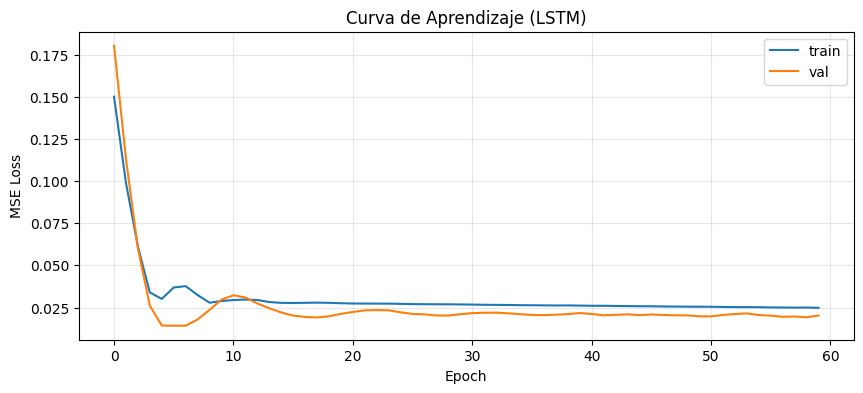

In [3]:

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Curva de Aprendizaje (LSTM)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 6. Predicción, métricas y visualización

Usaremos métricas en escala real:

- **RMSE**
- **MAE**

Y una gráfica comparando:

- Real
- Pred train (aprendizaje)
- Pred test (pronóstico)


In [4]:

from sklearn.metrics import mean_absolute_error, mean_squared_error

train_pred = model.predict(X_train, verbose=0)
test_pred = model.predict(X_test, verbose=0)

# Back to real scale
y_train_real = scaler.inverse_transform(y_train)
y_test_real = scaler.inverse_transform(y_test)
train_pred_real = scaler.inverse_transform(train_pred)
test_pred_real = scaler.inverse_transform(test_pred)

def rmse(y_true: np.ndarray, y_hat: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

train_rmse = rmse(y_train_real, train_pred_real)
test_rmse = rmse(y_test_real, test_pred_real)

train_mae = float(mean_absolute_error(y_train_real, train_pred_real))
test_mae = float(mean_absolute_error(y_test_real, test_pred_real))

print(f"Train RMSE: {train_rmse:.2f} | Train MAE: {train_mae:.2f}")
print(f" Test RMSE: {test_rmse:.2f} |  Test MAE: {test_mae:.2f}")


Train RMSE: 150.08 | Train MAE: 114.51
 Test RMSE: 135.88 |  Test MAE: 114.97


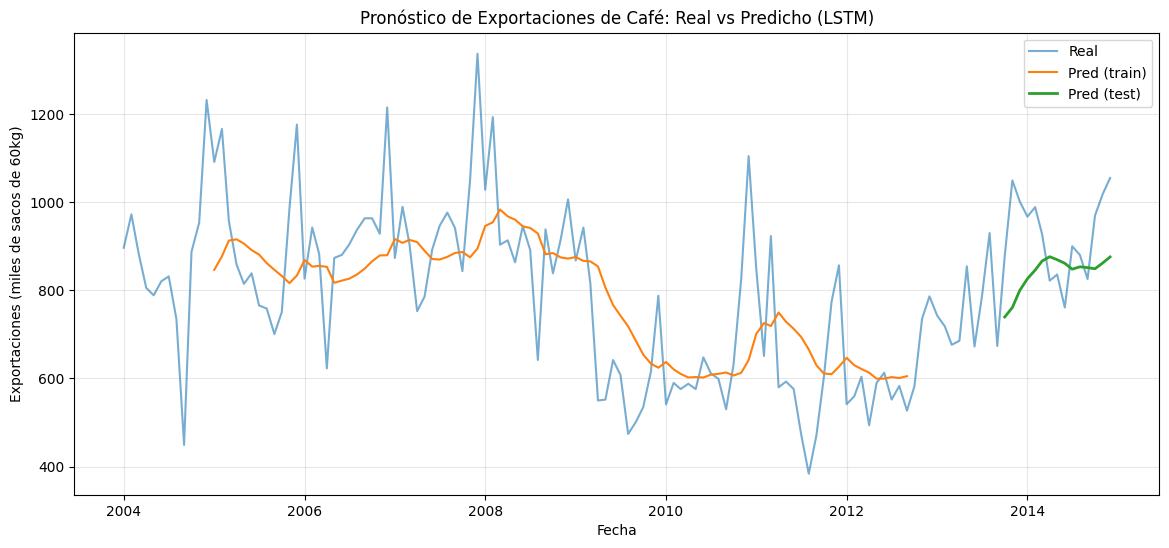

In [5]:

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Exportaciones"].values, label="Real", alpha=0.6)

full_real = df["Exportaciones"].values.reshape(-1, 1)
train_plot = np.full_like(full_real, fill_value=np.nan, dtype=float)
test_plot = np.full_like(full_real, fill_value=np.nan, dtype=float)

# Align predictions on the full timeline
train_plot[LOOK_BACK:split_idx, 0] = train_pred_real[:, 0]

test_start = split_idx + LOOK_BACK
test_end = test_start + len(test_pred_real)
test_plot[test_start:test_end, 0] = test_pred_real[:, 0]

plt.plot(df.index, train_plot[:, 0], label="Pred (train)")
plt.plot(df.index, test_plot[:, 0], label="Pred (test)", linewidth=2)

plt.title("Pronóstico de Exportaciones de Café: Real vs Predicho (LSTM)")
plt.xlabel("Fecha")
plt.ylabel("Exportaciones (miles de sacos de 60kg)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 7. Conclusiones: SimpleRNN vs LSTM

En general:

- **SimpleRNN:** memoria corta → tiende a seguir lo más reciente, puede “rezagarse”.
- **LSTM:** memoria controlada → suele capturar mejor estacionalidad y dependencias largas.

### ¿Por qué esto importa para el café?

- **Ciclo anual:** cosecha principal vs mitaca
- **Ciclo climático:** fenómenos como El Niño/La Niña (2–7 años)

Una SimpleRNN puede perder señal de eventos lejanos.  
La LSTM está diseñada para conservar (cuando conviene) información por más tiempo.



## 8. Reto final

1) Compara tus resultados (RMSE/MAE y gráfica) con el notebook anterior (SimpleRNN).  
2) Prueba con distintos `LOOK_BACK` (por ejemplo 6, 12, 24).

Pregunta guía:

> ¿Con qué ventana la LSTM empieza a capturar mejor la estacionalidad sin sobreajustar?
